# Confidence-threshold sweep

Measure the precision-coverage tradeoff induced by the hard confidence threshold and identify its effect on the final self-training error.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from matplotlib.ticker import LogitLocator, LogitFormatter, FuncFormatter
from scipy.special import logit, expit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    class_conditional_update_observables,
    trajectory_diagnostics,
    plot_macroscopic_evolution,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler


For $kappa\uparrow$, fewer observations are selected but they should be more reliable.  This notebook records the frontier
$$
\kappa\longmapsto (\omega^T,A_{\rm PL}^T)
$$
and the final error trajectory.  The $kappa=0$ point is the explicit all-selected experimental variant.

In [3]:
SEED = 3100
T, D, DELTA = 200, 1_000, 2.0
K_W, K_G = 4_500, 5_500
KAPPAS = np.array([kappa for kappa in np.linspace(logit(0.50), logit(0.99), 25)])

runs = {}
for index, kappa in enumerate(KAPPAS):
    cfg = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=float(kappa))
    runs[float(kappa)] = run_experiment(
        name=rf"kappa={kappa:.2f}", d=D, delta=DELTA, n_test=3_000,
        label_prior=0.5, rho=0.1, sigma=1.0, signal_std=1.0,
        algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
    )
summary = {
    kappa: state_evolution_update_observables(run)
    for kappa, run in runs.items()
}

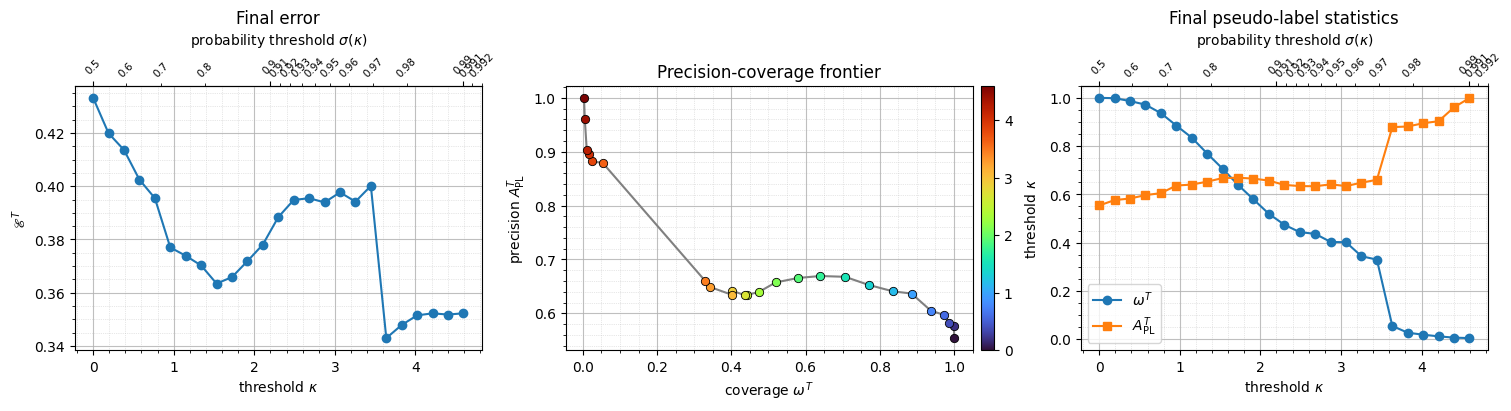

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.special import expit, logit
from matplotlib.ticker import LogitLocator, FuncFormatter

# Extract observables
final_error = np.array([state_evolution_state_observables(runs[float(k)])["error"][-1] for k in KAPPAS])
final_omega = np.array([summary[float(k)]["omega"][-1] for k in KAPPAS])
final_accuracy = np.array([summary[float(k)]["accuracy"][-1] for k in KAPPAS])

# Custom formatter ensuring clean standard decimal representations
def decimal_formatter(x, pos=None):
    if x <= 0 or x >= 1:
        return ""
    return f"{x:.4g}"

formatter = FuncFormatter(decimal_formatter)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# Plot 1
axes[0].plot(KAPPAS, final_error, marker="o")
axes[0].set(xlabel=r"threshold $\kappa$", ylabel=r"$\mathscr{E}^T$", title="Final error")
secax0 = axes[0].secondary_xaxis('top', functions=(expit, logit))
secax0.set_xlabel(r"probability threshold $\sigma(\kappa)$")

# Plot 2: Precision-Coverage Trajectories & Frontier
norm = mcolors.Normalize(vmin=np.min(KAPPAS), vmax=np.max(KAPPAS))
cmap = cm.turbo

# Explicitly connect the terminal states to form the frontier envelope
axes[1].plot(final_omega, final_accuracy, color="gray", linestyle="-", linewidth=1.5, alpha=1.0, zorder=2)

for k in KAPPAS:
    color = cmap(norm(float(k)))
    traj_omega = summary[float(k)]["omega"]
    traj_acc = summary[float(k)]["accuracy"]
    
    # Scatter the terminal point
    axes[1].scatter(traj_omega[-1], traj_acc[-1], color=color, edgecolor='black', linewidth=0.6, zorder=4)

axes[1].set(xlabel=r"coverage $\omega^T$", ylabel=r"precision $A_{\rm PL}^T$", title="Precision-coverage frontier")

# Attach colorbar heat map to the second subplot
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1], pad=0.02)
cbar.set_label(r"threshold $\kappa$", rotation=90, labelpad=8)

# Plot 3
axes[2].plot(KAPPAS, final_omega, marker="o", label=r"$\omega^T$")
axes[2].plot(KAPPAS, final_accuracy, marker="s", label=r"$A_{\rm PL}^T$")
axes[2].set(xlabel=r"threshold $\kappa$", title="Final pseudo-label statistics")
secax2 = axes[2].secondary_xaxis('top', functions=(expit, logit))
secax2.set_xlabel(r"probability threshold $\sigma(\kappa)$")

# Configure Secondary Axes (Logit scale ticks & fine grid lines)
for secax in [secax0, secax2]:
    secax.xaxis.set_major_locator(LogitLocator())
    secax.xaxis.set_major_formatter(formatter)
    secax.xaxis.set_minor_locator(LogitLocator(minor=True))
    secax.xaxis.set_minor_formatter(formatter)
    
    secax.tick_params(axis='x', which='both', labelsize=7.5, rotation=45)
    
    secax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)

# Configure Primary Axes (Turn on minor ticks & linear grid)
for ax in axes:
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.6)
    if ax.get_legend_handles_labels()[0]:
        ax.legend()

plt.show()

In [7]:
representative = KAPPAS[[0,8,17,19]]
expit(representative)

array([0.5       , 0.82225588, 0.96284795, 0.9743644 ])

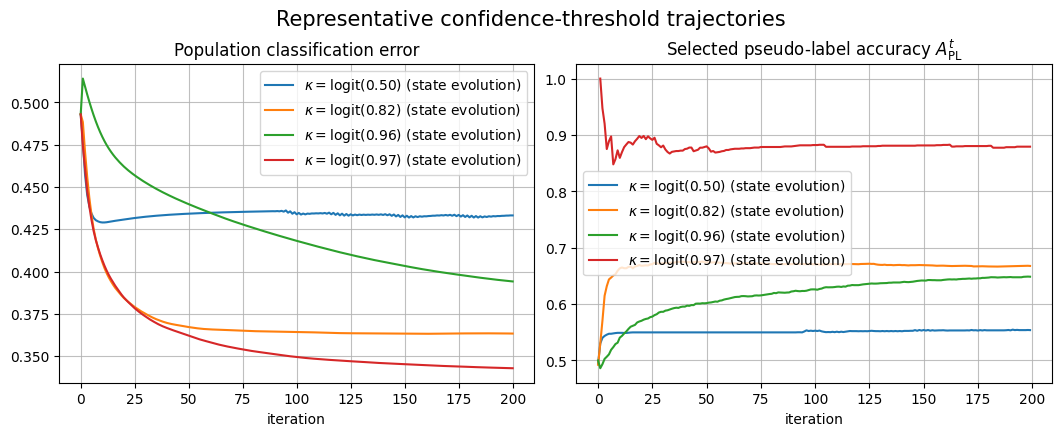

(<Figure size 1050x425 with 2 Axes>,
 array([[<Axes: title={'center': 'Population classification error'}, xlabel='iteration'>,
         <Axes: title={'center': 'Selected pseudo-label accuracy $A_{\\rm PL}^t$'}, xlabel='iteration'>]],
       dtype=object))

In [8]:
representative_runs = {
    rf"$\kappa=\mathrm{{logit}}({expit(kappa):.2f})$": runs[kappa]
    for kappa in representative
}
plot_macroscopic_evolution(
    representative_runs,
    quantities=("error", "accuracy"),
    sources=("state_evolution",),
    include_bayes=False,
    title="Representative confidence-threshold trajectories",
)

## Repeated threshold sweep

This calculation averages independent particle systems and reports standard errors (precision is undefined when no unlabeled particles are selected).

In [11]:
RUN_REPEATED_THRESHOLD_SWEEP = True
THRESHOLD_REPETITIONS = 10
if RUN_REPEATED_THRESHOLD_SWEEP:
    repeated = {float(kappa): [] for kappa in KAPPAS}
    for kappa_index, kappa in enumerate(KAPPAS):
        cfg = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=float(kappa))
        for repetition in range(THRESHOLD_REPETITIONS):
            repeated[float(kappa)].append(run_experiment(
                name=rf"kappa={kappa:.2f}, repetition={repetition}", d=D, delta=DELTA,
                n_test=3_000, label_prior=0.5, rho=0.1, sigma=1.0, signal_std=1.0,
                algo_cfg=cfg, seed=SEED + 10_000 * kappa_index + repetition,
                K_w=K_W, K_g=K_G,
            ))
    threshold_summary = {}
    for kappa, repeated_runs in repeated.items():
        terminal = np.array([trajectory_diagnostics(r)["terminal_error"] for r in repeated_runs])
        best = np.array([trajectory_diagnostics(r)["minimum_error"] for r in repeated_runs])
        update = [state_evolution_update_observables(r) for r in repeated_runs]
        threshold_summary[kappa] = {
            "terminal_error": (terminal.mean(), terminal.std(ddof=1) / np.sqrt(terminal.size)),
            "best_error": (best.mean(), best.std(ddof=1) / np.sqrt(best.size)),
            "omega": (np.array([u["omega"][-1] for u in update]).mean(), np.array([u["omega"][-1] for u in update]).std(ddof=1) / np.sqrt(len(update))),
            "accuracy": (np.nanmean([u["accuracy"][-1] for u in update]), np.nanstd([u["accuracy"][-1] for u in update], ddof=1) / np.sqrt(len(update))),
            "selected_mass": (np.array([u["correct_mass"][-1] + u["incorrect_mass"][-1] for u in update]).mean(), np.array([u["correct_mass"][-1] + u["incorrect_mass"][-1] for u in update]).std(ddof=1) / np.sqrt(len(update))),
        }
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for key, label in (("terminal_error", "terminal"), ("best_error", "best over time")):
        mean, se = np.asarray([threshold_summary[float(k)][key] for k in KAPPAS]).T
        axes[0].errorbar(KAPPAS, mean, yerr=se, marker="o", label=label)
    selected_mass = np.asarray([threshold_summary[float(k)]["selected_mass"] for k in KAPPAS]).T
    axes[1].errorbar(KAPPAS, selected_mass[0], yerr=selected_mass[1], marker="o", label="selected mass")
    axes[0].set(xlabel=r"threshold $\kappa$", title="Error with Monte Carlo standard errors")
    axes[1].set(xlabel=r"threshold $\kappa$", title="Unconditional selected mass")
    for ax in axes: ax.grid(alpha=0.3); ax.legend()
    plt.show()

: 

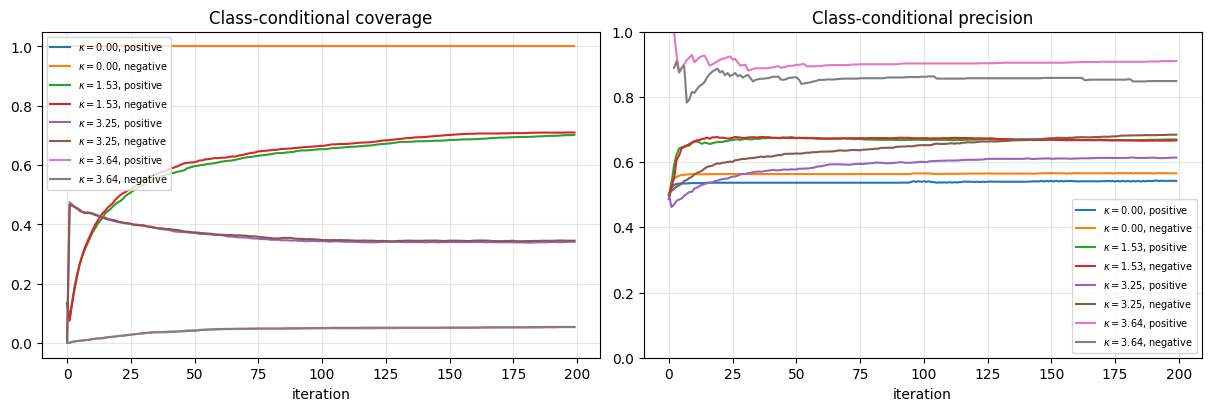

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for kappa in representative:
    conditional = class_conditional_update_observables(runs[kappa], source="state_evolution")
    for label, values in conditional.items():
        axes[0].plot(values["coverage"], label=rf"$\kappa={kappa:.2f}$, {label}")
        axes[1].plot(values["precision"], label=rf"$\kappa={kappa:.2f}$, {label}")
axes[0].set(title="Class-conditional coverage", xlabel="iteration")
axes[1].set(title="Class-conditional precision", xlabel="iteration", ylim=(0, 1))
for ax in axes: ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.show()